In [2]:
# load modules
using Revise
using Pkg
# Pkg.activate(joinpath(homedir(), "Projects/ATOMIC/ATOMIC_GOES/julia/ATOMIC_GOES"))
cd("/Users/deszoeks/Projects/ATOMIC/trade-cu-model/src/julia")
Pkg.activate(".")

using Printf, Dates, NCDatasets, JLD2
using Statistics, Interpolations, LinearAlgebra

# using PyPlot -> not thread safe in IJulia with Julia 1.12.4+
using PythonPlot
using VaporSat # dev ../../deps/VaporSat
includet("TradeCuModel.jl")
using .TradeCuModel

  Activating project at `~/Projects/ATOMIC/trade-cu-model/src/julia`


In [5]:
# parameters and initialization
KelvinCelsius=273.15 # K
zi   = 4.0e3    # m
ztop = 4.0e3
zcb  = 700      # m
divg = 1.5e-6   # 1/s
x = 0.53 # parameter precipitation efficiency

# ensemble of sink rates
ns = 600 # number of sink rates
tot_sink = range(6.3523e-4, 5.7e-3, length=ns) # min tuned for x=0.53 to get the highest possible cloud top
# tot_sink = (1 .+tanh.(range(-8*pi, 0, length=ns))) .* (5e-3 - 1e-4) .+ 1e-4
# tot_sink = range(6.1716e-4, 5.8e-3, length=ns) # min tuned for x=0.53 to get the highest possible cloud top

# get sounding data
z, tam, thm, qm, pm = get_mean_soundings()
#m  K       kg/kg Pa 
qs  = qsat.(pm, tam.-KelvinCelsius) # kg/kg
tvm  = virtual_temp.(tam, qm) # virtual temperature, K
thvm = virtual_temp.(thm, qm) # virtual potential temperature, K
dz = z[2]-z[1]
icb = findfirst(z .>= zcb) # cloud base index

# get An-Yi's aggregated GOES cloud fraction vs height data
rfv_nrm, rfv_acc, cth_bin = NCDataset("../../data/goes16_binned_low4km_20200115_20200219.nc") do dsa
    rfv_nrm = mean(dsa[:rfv_nrm][:,:], dims=2)
    rfv_acc = mean(dsa[:rfv_acc][:,:], dims=2)
    cth_bin = dsa[:cth_bin][:]
    return rfv_nrm, rfv_acc, cth_bin
end
#size(rfv_nrm), size(cth_bin) # (351,1)
# line up model grid and GOES cloud top height bins
offset = findfirst(x->x≈cth_bin[1]*1e3, z) - 1 # 50; cth_bin starts at z=500

rhoL = mean(filter(isfinite, calc_rhoL.(tvm, pm)[z.<=ztop])) # 2.41e6 J/m^3

# cloud base water flux from vapor and precipitation flux
# rhb_prate = mean(skipmissing(psl["prate"][:])) / 3600
rhb_prate = 8.88e-6 # kg s-1
Ecb = 180 # W/m^2; E0 - 35; just the cloud vapor flux
# all sky _total_ flux at cloud base
calc_cloud_mean(s,z) = mean(skipmissing(tmean(s)[z.<=ztop])) # 286.6K = mean Cu layer temperature
Gcb = Ecb/rhoL - rhb_prate

# specify the LS drying source profile due to
# subsidence and advection (also in TradeCuModel.jl)
"large scale subsidence vertical velocity (m/s)"
subsidence(z; divg=divg, zi=zi) = -min(z,zi) * divg # <0
# ^ negate on rhs
# large scale drying moisture source
function largescale_drying(q,z)
    wdqdz = subsidence.(z[1:end-1]) .* ddz(q,z)
    S_ls = -wdqdz .- 1.7e-8*max.(0, (4e3.-z[1:end-1])/4e3) 
end

# define LS source
S_ls = largescale_drying(qm,z)

# Total all-sky flux G with cloud base BC
G = Array{Union{Float64, Missing}}(missing, size(qm))
G[icb:end] = Gcb .+ vcat(0, cumsum( S_ls[icb:end] ) * dz)

F2 = calcF2(G, rfv_acc, offset; sk=1)

# coarsen bin size to 100 m
# F2c = calcF2(G, rfv_acc, offset; sk=10)
# mean not weighted by area
# F2m = mean(skipmissing(nisf2m.(F2)))
# mean weighted by area
F2m = sum( skipmissing(nisf2m.(F2) .* rfv_nrm[1:end-1]) ) / sum( rfv_nrm )
"The mean flux over all cloud categories i is $(round(F2m*1e3, digits=2)) g/kg m/s = $(round(F2m*rhoL, digits=0)) W/m²"

# align F2 to cloud model z grid
F2z = Array{Union{Missing, Float64}}(missing, size(qm))
F2z[offset.+eachindex(F2)] .= F2[:] 
# needs to be masked with 0 above cloud top

350-element view(::Vector{Union{Missing, Float64}}, 51:400) with eltype Union{Missing, Float64}:
  missing
  missing
  missing
  missing
  missing
  missing
  missing
  missing
  missing
  missing
  missing
  missing
  missing
 ⋮
 0.0018765468008889931
 0.001172699472574331
 0.0009900966123710794
 0.0018855248810130977
 0.001693570915762299
 0.0011938136303588003
 0.0010599366312624159
 0.0017626708292736127
 0.00231501858654747
 0.0022910659675441395
 0.002776960618210698
 0.0034911925000694313

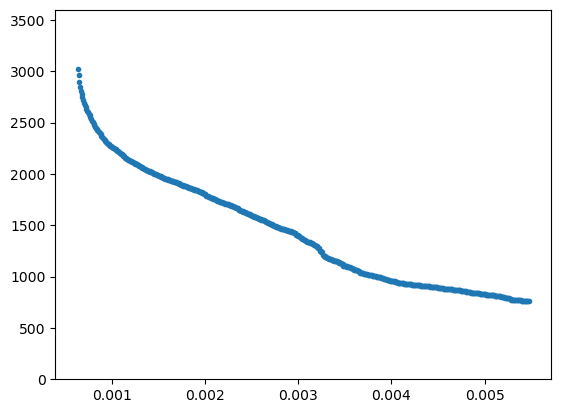

"Highest cloud top is 3.02 km for x=0.53 at sink rate 0.6352 km^-1.\n"

In [12]:
# run the cloud model

# initial cloud base humidity
qcb = qs[icb] # 0.0157

zt53, Fcld53, Fp53, qtc53 = cloudflux_1x(tot_sink; x=x, 
    z=z, nz=length(z), dz=z[2]-z[1],
    qm=qm, qs=qs, F2z=F2z, icb=icb, qcb=qcb)
Pcb53 = -Fp53[icb,:] # cloud base precip
# any(x->!ismissing(x), zt) # true!
ii = findall(x-> zcb+50<x<4000, zt53)
plot(tot_sink[ii], zt53[ii], marker=".", linestyle="none")
ylim([0, 3600])

"""
Highest cloud top is $(round(zt53[ii][1]/1e3, digits=2)) km \
for x=$(x) at sink rate $(round(tot_sink[ii[1]]*1e3, sigdigits=4)) km^-1.
"""